In [1]:
!pip install yfinance

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     ---------- ----------------------------- 0.8/3.0 MB 3.2 MB/s eta 0:00:01
     ------------------------ --------------- 1.8/3.0 MB 4.3 MB/s eta 0:00:01
     -------------------------------------- - 2.9/3.0 MB 5.1 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 3.6 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ----------------------------------------

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [3]:
btc = yf.Ticker('BTC-USD')
prices1 = btc.history(period='5y')
prices1.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

eth = yf.Ticker('ETH-USD')
prices2 = eth.history(period='5y')
prices2.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

usdt = yf.Ticker('USDT-USD')
prices3 = usdt.history(period='5y')
prices3.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

bnb = yf.Ticker('BNB-USD')
prices4 = bnb.history(period='5y')
prices4.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

In [4]:
p1 = prices1.join(prices2, lsuffix = ' (BTC)', rsuffix = ' (ETH)')
p2 = prices3.join(prices4, lsuffix = ' (USDT)', rsuffix = ' (BNB)')
data = p1.join(p2, lsuffix = '_', rsuffix = '_')

In [5]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-01-06 00:00:00+00:00,36824.363281,75289433811,1207.112183,44699914188,1.001528,116105139289,42.165955,641021601
2021-01-07 00:00:00+00:00,39371.042969,84762141031,1225.678101,40468027280,1.000400,129467601516,43.449490,829964770
2021-01-08 00:00:00+00:00,40797.609375,88107519480,1224.197144,44334826666,1.000045,131555961745,42.395317,650561500
2021-01-09 00:00:00+00:00,40254.546875,61984162837,1281.077271,33233105361,1.002947,103292241007,43.932854,590039660
2021-01-10 00:00:00+00:00,38356.441406,79980747690,1262.246704,40616938053,1.000223,135437984723,42.448475,701488832


In [6]:
data.tail()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2026-01-02 00:00:00+00:00,89944.695312,46398906171,3124.422607,25242778003,0.999672,96128566387,880.844177,2274583336
2026-01-03 00:00:00+00:00,90603.187500,20774828592,3125.917480,11460707919,0.999635,55660104876,878.639465,1660447864
2026-01-04 00:00:00+00:00,91413.492188,26770491368,3140.710449,13890479323,0.999506,66989138853,894.383667,1869811425
2026-01-05 00:00:00+00:00,93882.554688,53376407252,3226.130371,27211995956,0.999919,109110758515,910.788391,2191450063
2026-01-06 00:00:00+00:00,93441.906250,46307950592,3225.332275,24735717376,0.999590,101637128192,912.238220,2119668096


In [7]:
data.shape

(1827, 8)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2021-01-06 00:00:00+00:00 to 2026-01-06 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1827 non-null   float64
 1   Volume (BTC)   1827 non-null   int64  
 2   Close (ETH)    1827 non-null   float64
 3   Volume (ETH)   1827 non-null   int64  
 4   Close (USDT)   1827 non-null   float64
 5   Volume (USDT)  1827 non-null   int64  
 6   Close (BNB)    1827 non-null   float64
 7   Volume (BNB)   1827 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.5 KB


In [9]:
data.isna().sum()

Close (BTC)      0
Volume (BTC)     0
Close (ETH)      0
Volume (ETH)     0
Close (USDT)     0
Volume (USDT)    0
Close (BNB)      0
Volume (BNB)     0
dtype: int64

In [10]:
data.describe()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03
mean,54608.810432,3.708765e+10,2541.189798,1.949275e+10,1.000144,7.088206e+10,459.530444,1.848884e+09
std,29507.923285,2.299208e+10,908.013288,1.289646e+10,0.000709,4.501286e+10,221.018890,1.475701e+09
min,15787.284180,5.331173e+09,993.636780,2.081626e+09,0.995872,9.989859e+09,38.111610,2.038465e+08
25%,29412.204102,2.130695e+10,1794.544312,1.025234e+10,0.999893,4.011224e+10,287.933655,8.837919e+08
50%,46627.777344,3.175896e+10,2458.726562,1.643428e+10,1.000141,6.038998e+10,402.450043,1.601745e+09
75%,69361.058594,4.702226e+10,3234.704468,2.500993e+10,1.000383,8.808248e+10,600.281342,2.202072e+09
max,124752.531250,3.509679e+11,4831.348633,9.773662e+10,1.011530,3.443980e+11,1310.214355,1.798295e+10


# Exploratory Data Analysis

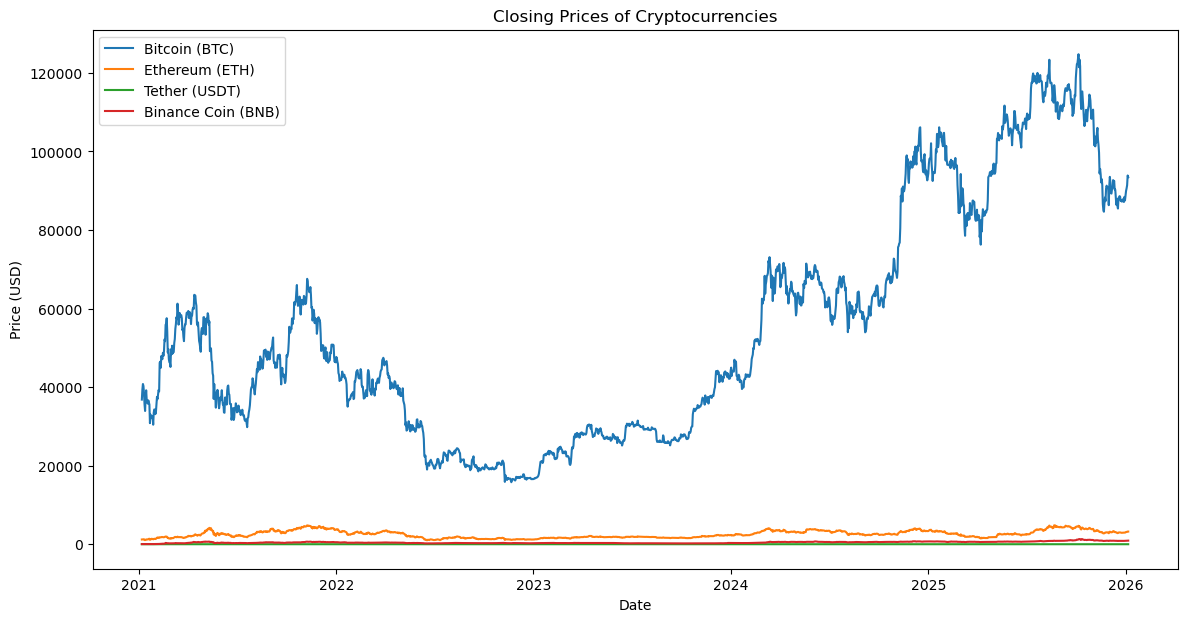

In [11]:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Close (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Close (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Close (BNB)'], label='Binance Coin (BNB)')
plt.title('Closing Prices of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

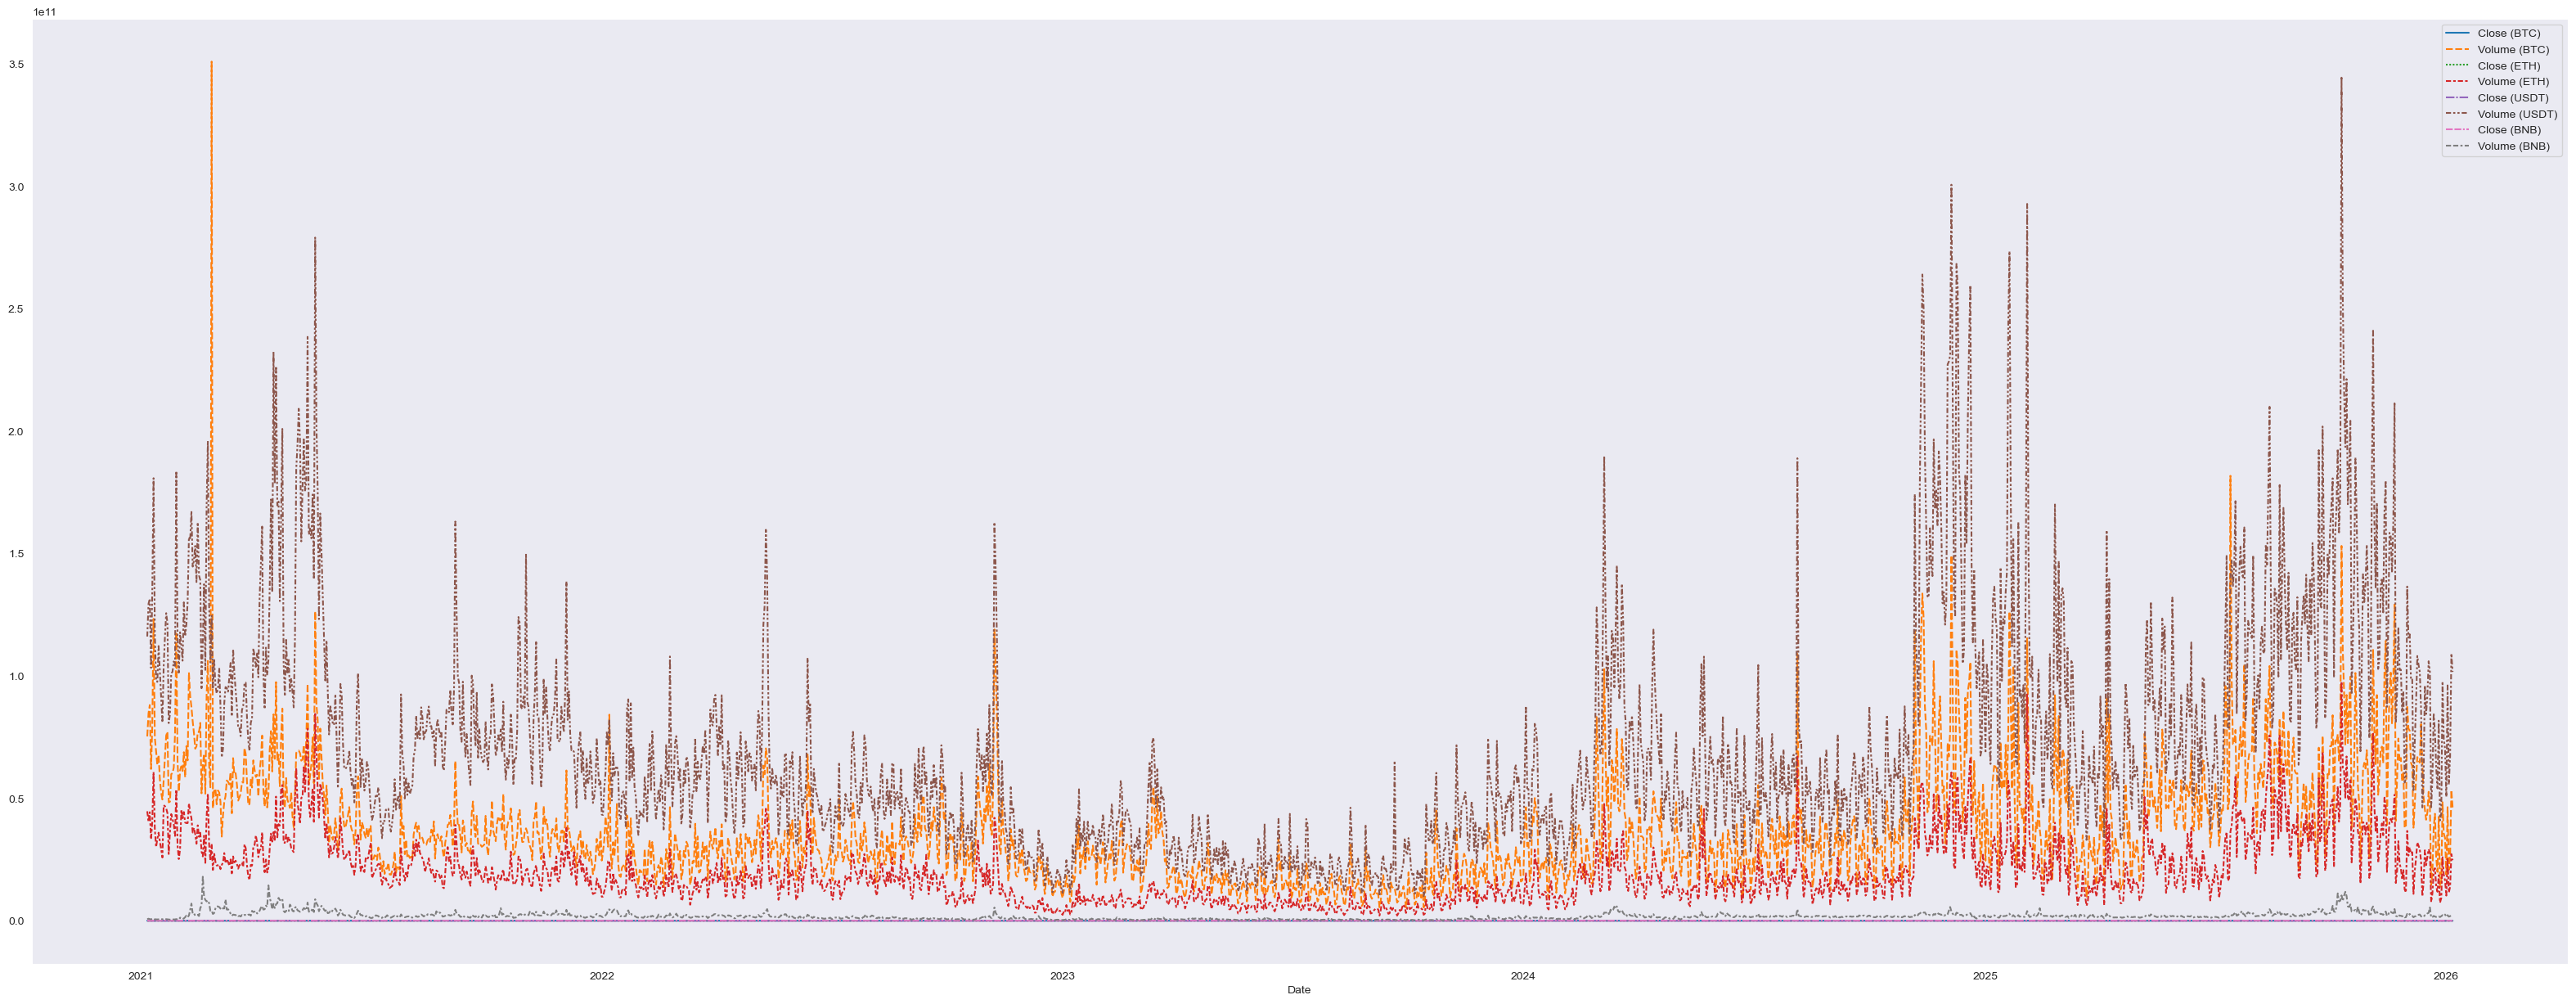

In [13]:
plt.figure(figsize = (40,15))
sns.set_style('dark')
sns.lineplot(data=data)
plt.show()

## Visualizing The Trading Volumes Of All Four Crypto-Currencies

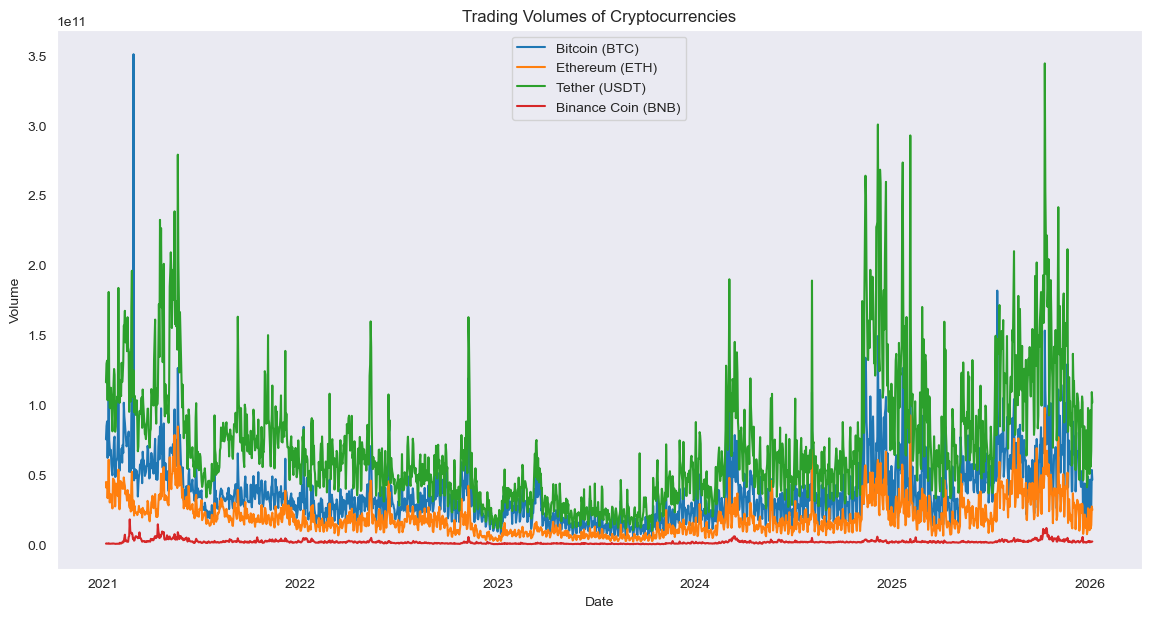

In [16]:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Volume (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Volume (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Volume (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Volume (BNB)'], label='Binance Coin (BNB)')
plt.title('Trading Volumes of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()

### Correlation Analysis

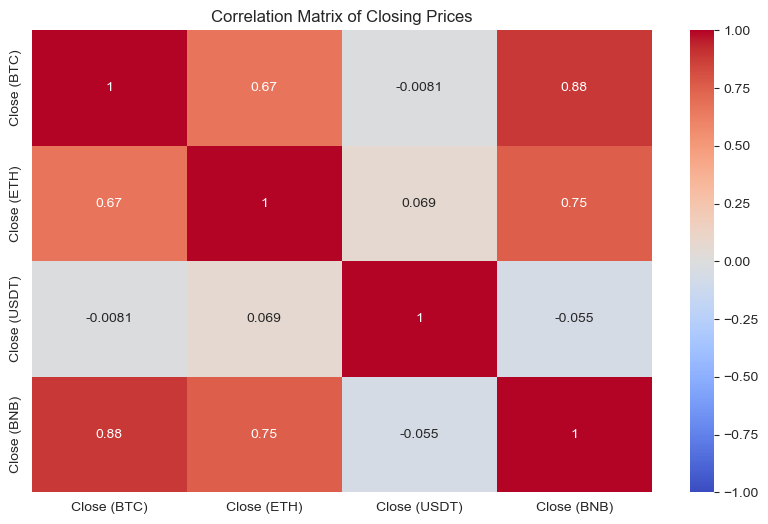

In [15]:
corr_matrix = data[['Close (BTC)', 'Close (ETH)', 'Close (USDT)', 'Close (BNB)']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Closing Prices')
plt.show()


## Distribution Of Closing Prices Of Each Crypto-Currencies

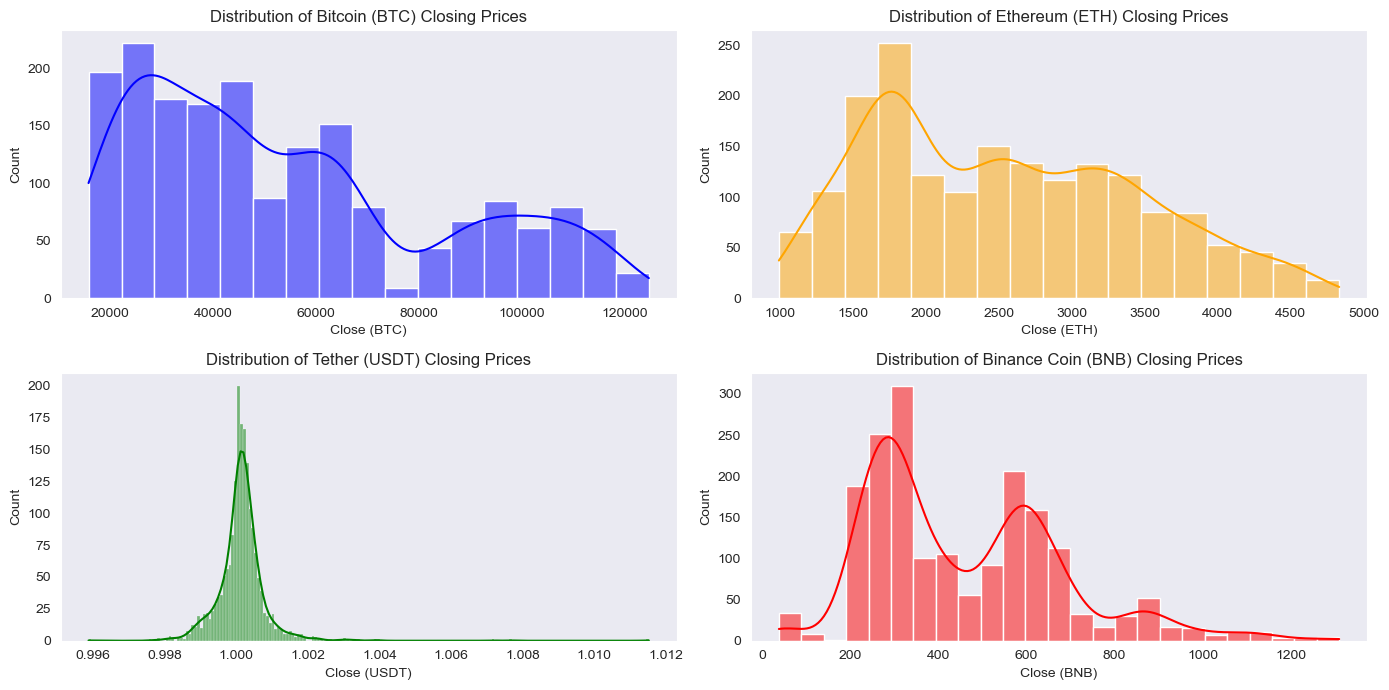

In [17]:
plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(data['Close (BTC)'], kde=True, color='blue')
plt.title('Distribution of Bitcoin (BTC) Closing Prices')

plt.subplot(2, 2, 2)
sns.histplot(data['Close (ETH)'], kde=True, color='orange')
plt.title('Distribution of Ethereum (ETH) Closing Prices')

plt.subplot(2, 2, 3)
sns.histplot(data['Close (USDT)'], kde=True, color='green')
plt.title('Distribution of Tether (USDT) Closing Prices')

plt.subplot(2, 2, 4)
sns.histplot(data['Close (BNB)'], kde=True, color='red')
plt.title('Distribution of Binance Coin (BNB) Closing Prices')

plt.tight_layout()
plt.show()

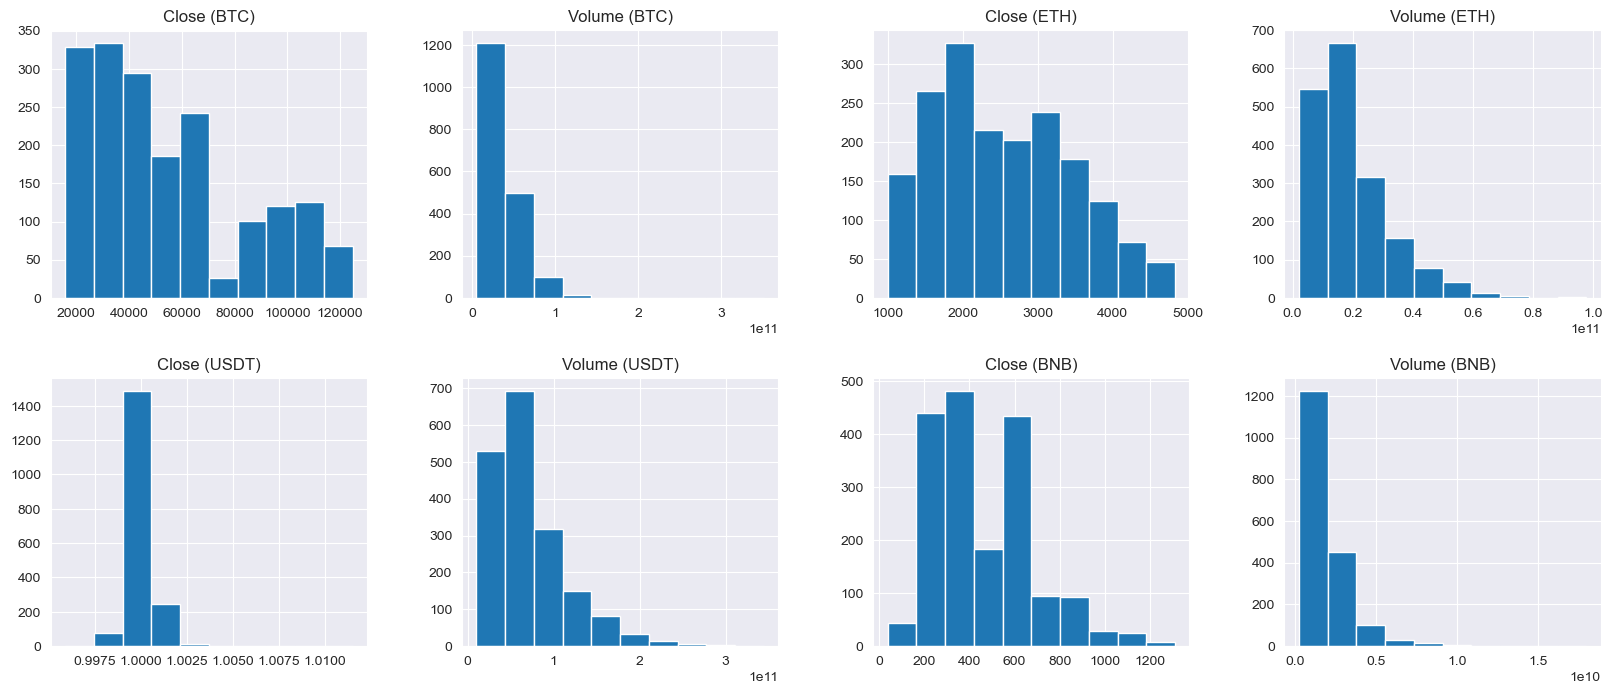

In [18]:
data.hist(figsize=(20, 8), layout=(2, 4))
plt.show()

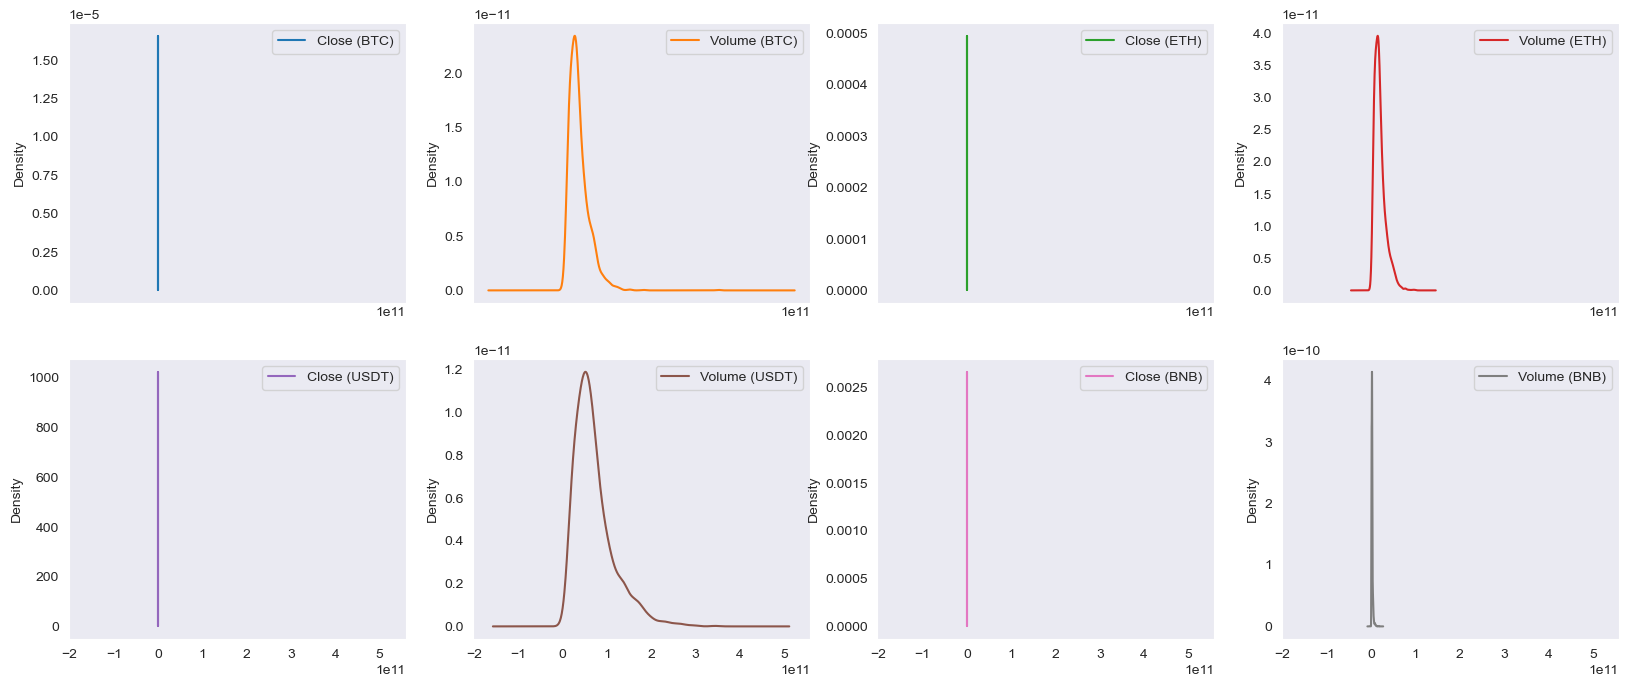

In [19]:
data.plot(kind = "kde", subplots = True, layout = (2, 4), figsize = (20, 8))
plt.show()

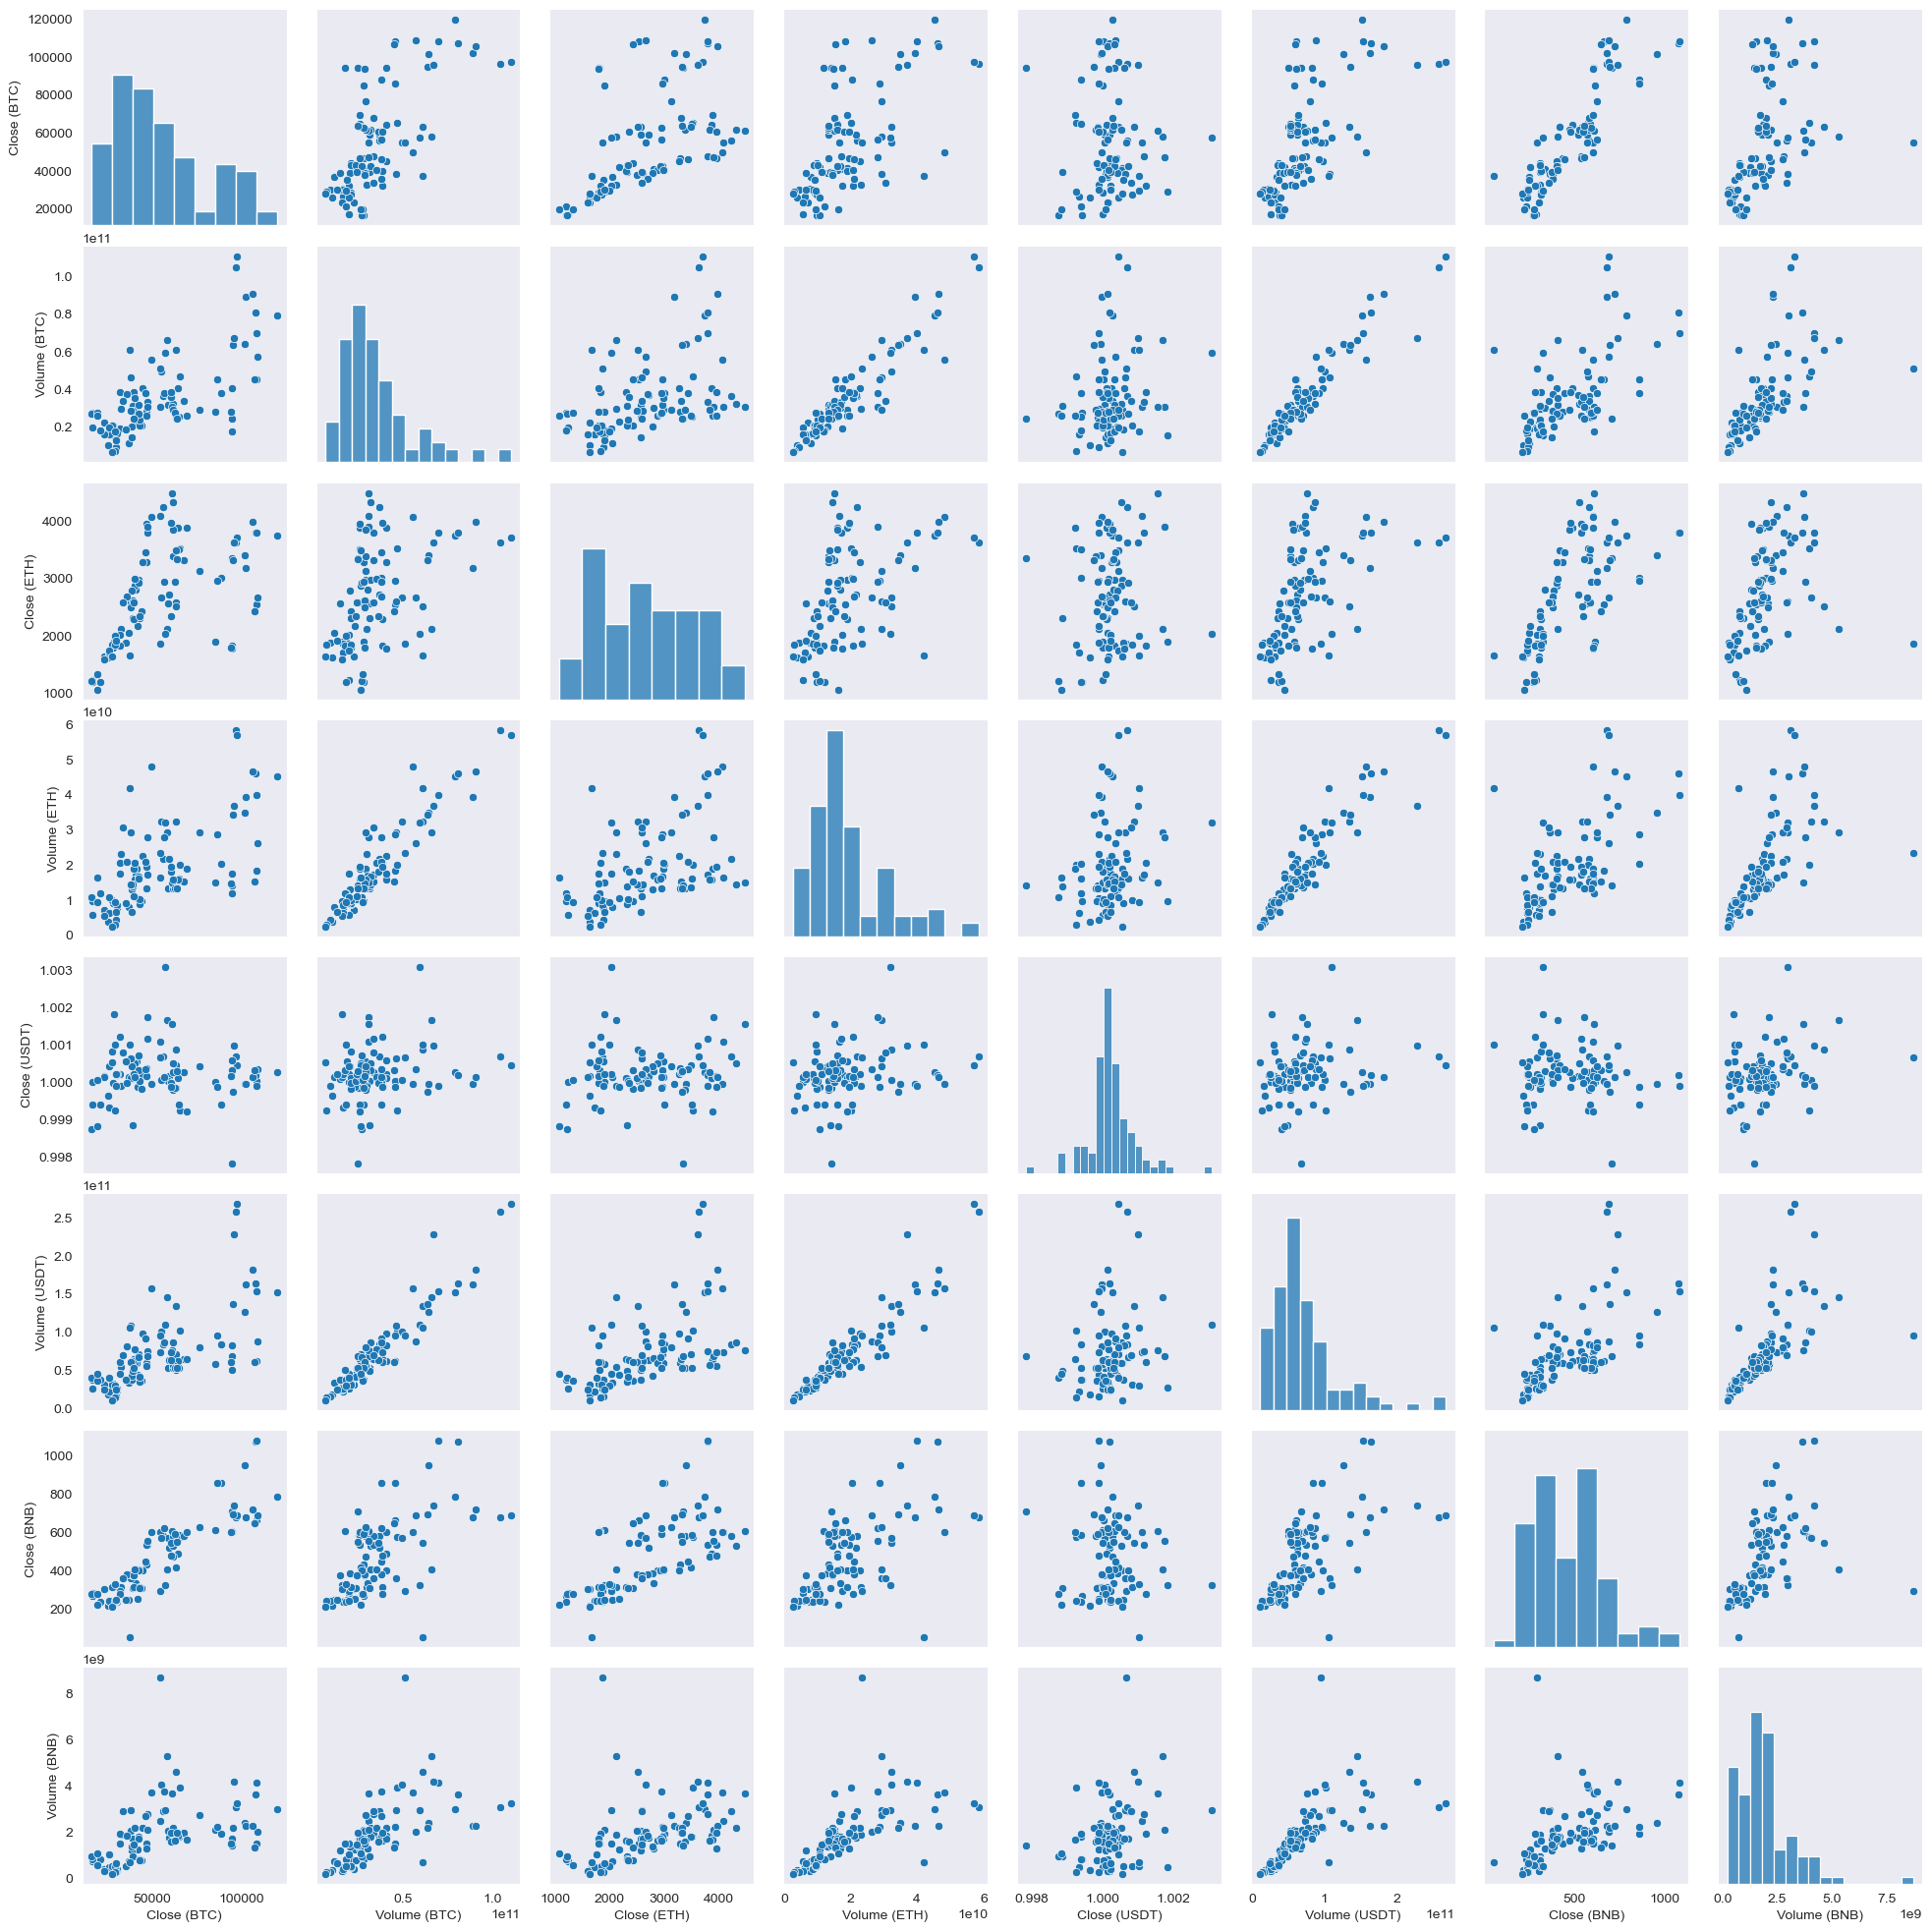

In [20]:
sns.pairplot(data.sample(n=100))
plt.show()

## Data Pre-Processing

In [24]:
X = data.drop(columns = ['Close (BTC)'], axis = 1)
Y = data.loc[:, 'Close (BTC)']

In [25]:
X.head()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2021-01-06 00:00:00+00:00,75289433811,1207.112183,44699914188,1.001528,116105139289,42.165955,641021601
2021-01-07 00:00:00+00:00,84762141031,1225.678101,40468027280,1.000400,129467601516,43.449490,829964770
2021-01-08 00:00:00+00:00,88107519480,1224.197144,44334826666,1.000045,131555961745,42.395317,650561500
2021-01-09 00:00:00+00:00,61984162837,1281.077271,33233105361,1.002947,103292241007,43.932854,590039660
2021-01-10 00:00:00+00:00,79980747690,1262.246704,40616938053,1.000223,135437984723,42.448475,701488832


In [26]:
X.tail()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-01-02 00:00:00+00:00,46398906171,3124.422607,25242778003,0.999672,96128566387,880.844177,2274583336
2026-01-03 00:00:00+00:00,20774828592,3125.917480,11460707919,0.999635,55660104876,878.639465,1660447864
2026-01-04 00:00:00+00:00,26770491368,3140.710449,13890479323,0.999506,66989138853,894.383667,1869811425
2026-01-05 00:00:00+00:00,53376407252,3226.130371,27211995956,0.999919,109110758515,910.788391,2191450063
2026-01-06 00:00:00+00:00,46307950592,3225.332275,24735717376,0.999590,101637128192,912.238220,2119668096


In [27]:
Y.head()

Date
2021-01-06 00:00:00+00:00    36824.363281
2021-01-07 00:00:00+00:00    39371.042969
2021-01-08 00:00:00+00:00    40797.609375
2021-01-09 00:00:00+00:00    40254.546875
2021-01-10 00:00:00+00:00    38356.441406
Name: Close (BTC), dtype: float64

In [28]:
Y.tail()

Date
2026-01-02 00:00:00+00:00    89944.695312
2026-01-03 00:00:00+00:00    90603.187500
2026-01-04 00:00:00+00:00    91413.492188
2026-01-05 00:00:00+00:00    93882.554688
2026-01-06 00:00:00+00:00    93441.906250
Name: Close (BTC), dtype: float64

### Splitting The Data Into Training Set And Testing Set

In [31]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.20,random_state=0)

In [32]:
print(f'X_train shape :{X_train.shape}')
print(f'X_test shape : {X_test.shape}')
print(f'Y_train shape : {Y_train.shape}')
print(f'Y_test shape : {Y_test.shape}')

X_train shape :(1461, 7)
X_test shape : (366, 7)
Y_train shape : (1461,)
Y_test shape : (366,)


### Parameter SelectKBest

In [33]:
from sklearn.feature_selection import SelectKBest

fs = SelectKBest(k=4)
X_train = fs.fit_transform(X_train,Y_train)
X_test = fs.transform(X_test)

C:\Users\Neha\Documents\it\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:108: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [34]:
mask = fs.get_support()
selected_features = X.columns[mask]
print('Selected Features :',selected_features)

Selected Features : Index(['Close (USDT)', 'Volume (USDT)', 'Close (BNB)', 'Volume (BNB)'], dtype='object')


In [35]:
X_train

array([[1.00020099e+00, 6.17842012e+10, 4.30508820e+02, 1.47089925e+09],
       [1.00071001e+00, 7.75461940e+10, 4.48920258e+02, 2.12066073e+09],
       [1.00002503e+00, 7.14139261e+10, 2.77576935e+02, 1.13695607e+09],
       ...,
       [1.00069296e+00, 1.45287867e+11, 7.21211975e+02, 2.87768145e+09],
       [1.00009203e+00, 7.71605487e+10, 2.68817322e+02, 1.92580545e+09],
       [9.99089003e-01, 5.45582938e+10, 2.54168259e+02, 1.09485066e+09]])

### MinMaxScaler

In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Implementing 10 Different Algorithms

In [37]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error,r2_score

----- Linear Regression -----
Mean Squared Error (MSE): 148772817.88602644
R-squared: 0.826364664550014

----- Ridge Regression -----
Mean Squared Error (MSE): 148812682.8732552
R-squared: 0.8263181374321673

----- Lasso Regression -----
Mean Squared Error (MSE): 148750706.2541174
R-squared: 0.826390471419027

----- ElasticNet Regression -----
Mean Squared Error (MSE): 752401910.1500498
R-squared: 0.1218586841435042

----- Support Vector Regression (SVR) -----
Mean Squared Error (MSE): 898037946.1828392
R-squared: -0.048115658814308127

----- Decision Tree Regression -----
Mean Squared Error (MSE): 101687398.68730384
R-squared: 0.881318873749955

----- Random Forest Regression -----
Mean Squared Error (MSE): 45910816.46028496
R-squared: 0.9464166900235002

----- Gradient Boosting Regression -----
Mean Squared Error (MSE): 57040561.18354619
R-squared: 0.933426971969113

----- K-Nearest Neighbors Regression -----
Mean Squared Error (MSE): 52560516.20394884
R-squared: 0.9386557101480144



C:\Users\Neha\Documents\it\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


----- Neural Network Regression (MLP) -----
Mean Squared Error (MSE): 503168719.53270084
R-squared: 0.41274306257388926

                             Model           MSE  R-squared
0                Linear Regression  1.487728e+08   0.826365
1                 Ridge Regression  1.488127e+08   0.826318
2                 Lasso Regression  1.487507e+08   0.826390
3            ElasticNet Regression  7.524019e+08   0.121859
4  Support Vector Regression (SVR)  8.980379e+08  -0.048116
5         Decision Tree Regression  1.016874e+08   0.881319
6         Random Forest Regression  4.591082e+07   0.946417
7     Gradient Boosting Regression  5.704056e+07   0.933427
8   K-Nearest Neighbors Regression  5.256052e+07   0.938656
9  Neural Network Regression (MLP)  5.031687e+08   0.412743


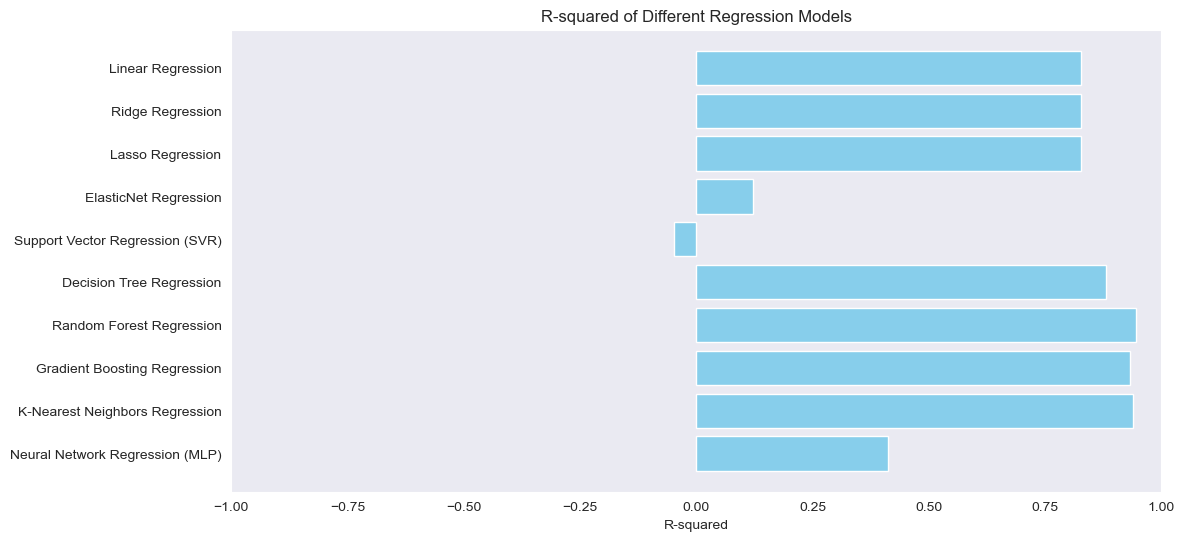

In [38]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Support Vector Regression (SVR)': SVR(kernel='rbf'),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'Neural Network Regression (MLP)': MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam')
}
results = {'Model': [], 'MSE': [], 'R-squared': []}

for name, model in models.items():
    model.fit(X_train, Y_train)

    Y_pred = model.predict(X_test)

    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R-squared'].append(r2)

    print(f"----- {name} -----")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared: {r2}")
    print()

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R-squared'], color='skyblue')
plt.xlabel('R-squared')
plt.title('R-squared of Different Regression Models')
plt.xlim(-1, 1)
plt.gca().invert_yaxis()
plt.show()

## Random Forest Regressor

In [39]:
import pickle
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

X, Y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=0)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_rf = RandomForestRegressor(n_estimators=100, random_state=0)

model_rf.fit(X_train, Y_train)

filename = 'random_forest_model.pkl'
pickle.dump(model_rf, open(filename, 'wb'))

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

loaded_model = pickle.load(open(filename, 'rb'))

Y_pred = loaded_model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Loaded Random Forest Regression - Mean Squared Error (MSE): {mse}")
print(f"Loaded Random Forest Regression - R-squared: {r2}")

Loaded Random Forest Regression - Mean Squared Error (MSE): 44768612.982179254
Loaded Random Forest Regression - R-squared: 0.9477497755084102
